In [1]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix

In [2]:
# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# LOAD DATASET (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # required for ResNet
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset.classes

C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


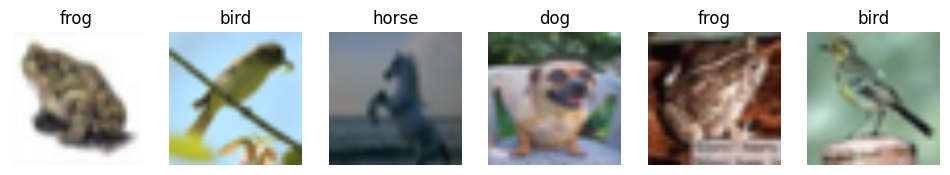

In [4]:
# SHOW SAMPLE IMAGES
def show_images(loader):
    images, labels = next(iter(loader))
    
    fig, axes = plt.subplots(1, 6, figsize=(12,4))
    for i in range(6):
        axes[i].imshow(images[i].permute(1,2,0))
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')
    plt.show()

show_images(train_loader)

In [5]:
# LOAD PRETRAINED RESNET18
model = torchvision.models.resnet18(pretrained=True)

# Modify final layer
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
# LOSS & OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# TRAIN MODEL
epochs = 3

train_losses = []
train_acc = []

for epoch in range(epochs):
    running_loss = 0
    correct = 0
    total = 0
    
    model.train()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_losses.append(running_loss)
    train_acc.append(correct/total)
    
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Accuracy: {correct/total:.4f}")

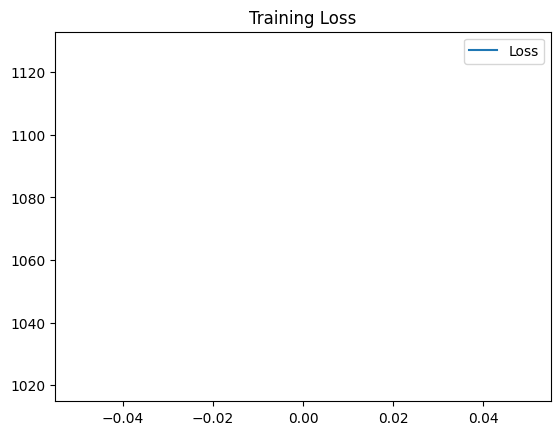

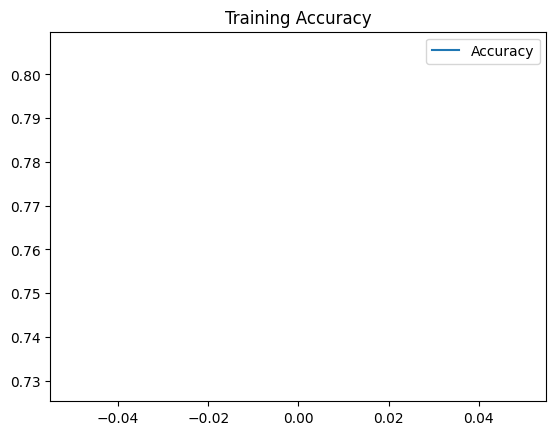

In [8]:
# TRAINING GRAPHS
plt.plot(train_losses, label="Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

plt.plot(train_acc, label="Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.show()

In [9]:
# EVALUATION
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

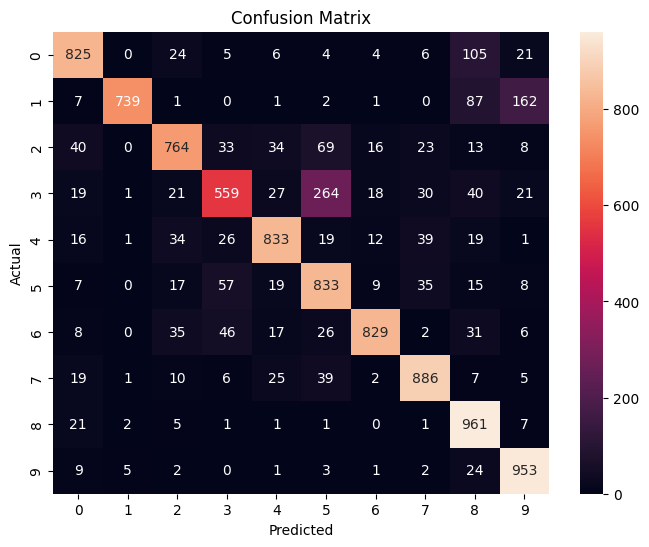

In [10]:
# CONFUSION MATRIX
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
# PREDICTION FUNCTION
def predict_image(image, model):
    model.eval()
    image = image.to(device)
    
    with torch.no_grad():
        output = model(image.unsqueeze(0))
        _, pred = torch.max(output, 1)
    
    return classes[pred.item()]

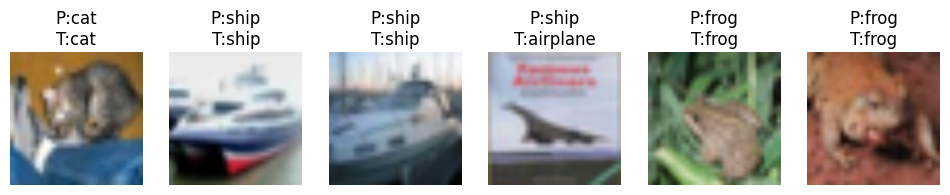

In [12]:
# SHOW PREDICTIONS
def show_predictions():
    images, labels = next(iter(test_loader))
    images = images.to(device)
    
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    
    fig, axes = plt.subplots(1, 6, figsize=(12,4))
    for i in range(6):
        axes[i].imshow(images[i].cpu().permute(1,2,0))
        axes[i].set_title(f"P:{classes[preds[i]]}\nT:{classes[labels[i]]}")
        axes[i].axis('off')
    
    plt.show()

show_predictions()

In [13]:
## Conclusion

# Used ResNet18 for transfer learning
# Trained on CIFAR-10 dataset
# Visualized training performance
# Evaluated using confusion matrix
# Model successfully predicts image classes